In [ ]:
from google.colab import files
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
username = 'silenthydreigon'   # Kaggle username
key    = 'KGAT_a0a5555f1590de9ffc576450821a2437'   # API token

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': username, 'key': key}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('Kaggle configured!')

Kaggle configured!


In [ ]:
dataset_id = 'debashishsau/aslamerican-sign-language-aplhabet-dataset'

!kaggle datasets download -d {dataset_id}

print(f"Dataset '{dataset_id}' downloaded successfully.")

Dataset URL: https://www.kaggle.com/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset
License(s): CC0-1.0
100% 4.20G/4.20G [00:34<00:00, 130MB/s]

Dataset 'debashishsau/aslamerican-sign-language-aplhabet-dataset' downloaded successfully.


In [ ]:
!unzip aslamerican-sign-language-aplhabet-dataset.zip -d /content/data/

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2863).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2864).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2865).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2866).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2867).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2868).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2869).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (287).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2870).jpg  
  inflating: /content/data/ASL_Alphabet_Dataset/asl_alphabet_train/space/space (2871).jpg  
  inflating: /content/data/ASL

In [ ]:
!kaggle datasets download -d rayeed045/american-sign-language-digit-dataset
!unzip american-sign-language-digit-dataset.zip -d /content/data/

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Images - Sign 5/Sign 5 (103).jpeg  
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Images - Sign 5/Sign 5 (104).jpeg  
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Images - Sign 5/Sign 5 (105).jpeg  
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Images - Sign 5/Sign 5 (106).jpeg  
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Images - Sign 5/Sign 5 (107).jpeg  
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Images - Sign 5/Sign 5 (108).jpeg  
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Images - Sign 5/Sign 5 (109).jpeg  
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Images - Sign 5/Sign 5 (11).jpeg  
  inflating: /content/data/American Sign Language Digits Dataset/5/Input Image

In [ ]:
# Configuration
batch_size = 32
img_height = 64
img_width = 64

# Paths
letters_path = '/content/data/ASL_Alphabet_Dataset/asl_alphabet_train'
numbers_path = '/content/data/American Sign Language Digits Dataset'

# Load Letters
train_letters = tf.keras.utils.image_dataset_from_directory(
    letters_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_letters = tf.keras.utils.image_dataset_from_directory(
    letters_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

# Load Numbers
train_numbers = tf.keras.utils.image_dataset_from_directory(
    numbers_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_numbers = tf.keras.utils.image_dataset_from_directory(
    numbers_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

train_ds = train_letters.concatenate(train_numbers)
val_ds = val_letters.concatenate(val_numbers)

all_class_names = train_letters.class_names + train_numbers.class_names
num_classes = len(all_class_names)

print(f"Success! Total classes: {num_classes}")
print(f"Classes: {all_class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 223074 files belonging to 29 classes.
Using 178460 files for training.
Found 223074 files belonging to 29 classes.
Using 44614 files for validation.
Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.
Success! Total classes: 39
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:

tf.keras.backend.clear_session()

num_classes = len(all_class_names)

model = models.Sequential([
    # Input & Preprocessing
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),

    # Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),

    # Feature Extraction
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

model.save('asl_classifier_model.h5')

Starting training...
Epoch 1/10
5827/5827 ━━━━━━━━━━━━━━━━━━━━ 249s 38ms/step - accuracy: 0.3577 - loss: 2.0873 - val_accuracy: 0.7118 - val_loss: 0.9850
Epoch 2/10
5827/5827 ━━━━━━━━━━━━━━━━━━━━ 259s 37ms/step - accuracy: 0.6209 - loss: 1.1584 - val_accuracy: 0.8322 - val_loss: 0.5588
Epoch 3/10
5827/5827 ━━━━━━━━━━━━━━━━━━━━ 259s 37ms/step - accuracy: 0.6958 - loss: 0.9211 - val_accuracy: 0.8587 - val_loss: 0.4553
Epoch 4/10
5827/5827 ━━━━━━━━━━━━━━━━━━━━ 239s 36ms/step - accuracy: 0.7336 - loss: 0.8104 - val_accuracy: 0.8793 - val_loss: 0.3897
Epoch 5/10
5827/5827 ━━━━━━━━━━━━━━━━━━━━ 236s 36ms/step - accuracy: 0.7591 - loss: 0.7305 - val_accuracy: 0.8765 - val_loss: 0.3891
Epoch 6/10
5827/5827 ━━━━━━━━━━━━━━━━━━━━ 303s 43ms/step - accuracy: 0.7792 - loss: 0.6744 - val_accuracy: 0.8969 - val_loss: 0.3324
Epoch 7/10
5827/5827 ━━━━━━━━━━━━━━━━━━━━ 231s 35ms/step - accuracy: 0.7917 - loss: 0.6366 - val_accuracy: 0.9062 - val_loss: 0.2967
Epoch 8/10
5827/5827 ━━━━━━━━━━━━━━━━━━━━ 261s 3

1458/1458 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9206 - loss: 0.2571

Final Validation Accuracy: 92.06%


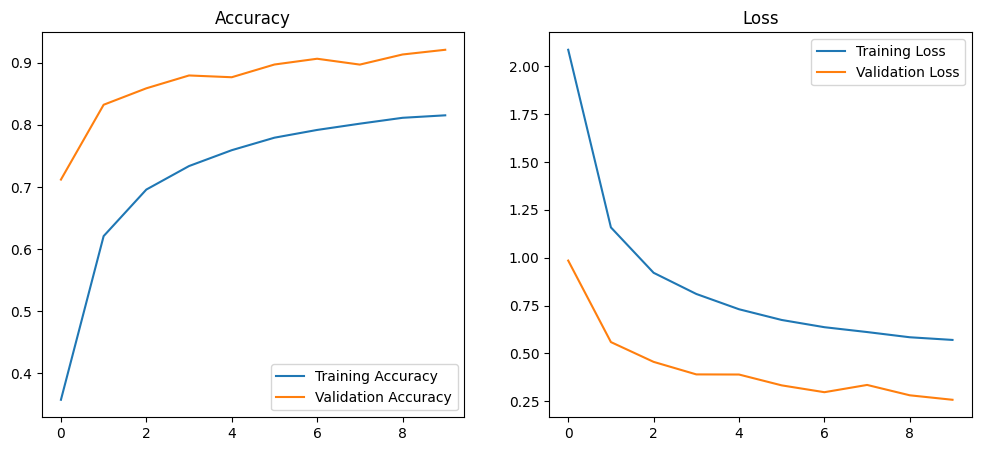

In [ ]:
# Evaluate on the validation set
loss, accuracy = model.evaluate(val_ds)
print(f"\nFinal Validation Accuracy: {accuracy * 100:.2f}%")

# Plotting Training & Validation History
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history)